In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    classification_report
)


In [ ]:
#load data

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)



In [38]:
# ============================================================
# 2. 70/15/15 SPLIT (MANDATORY)
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)


In [39]:

# ============================================================
# 3. SCALING (ONLY TRAIN STATISTICS)
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


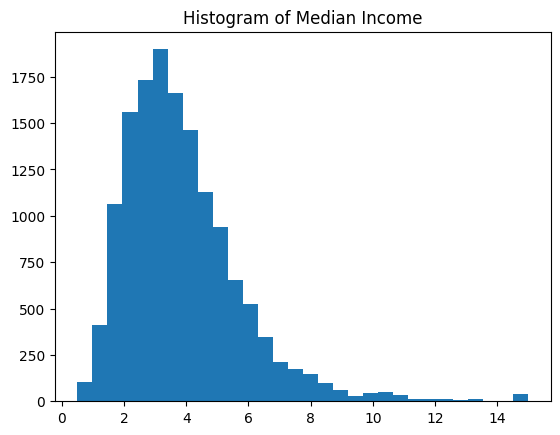

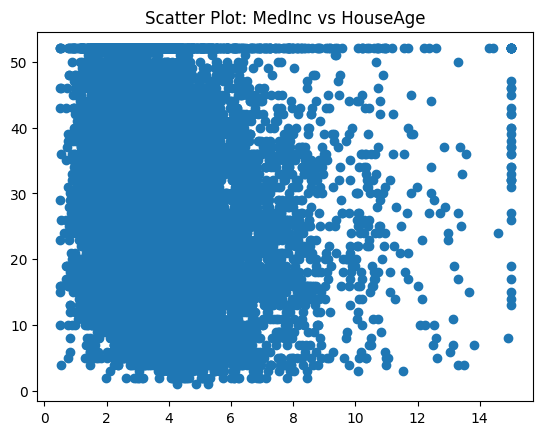

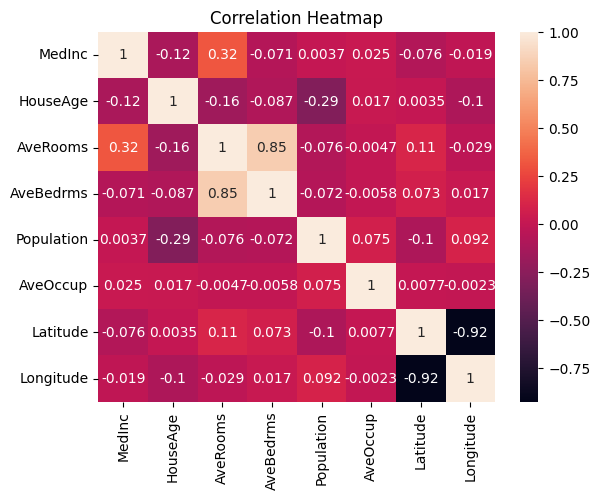

In [40]:

# ============================================================
# 4. EDA (Training Only)
# ============================================================

plt.hist(X_train["MedInc"], bins=30)
plt.title("Histogram of Median Income")
plt.show()

plt.scatter(X_train["MedInc"], X_train["HouseAge"])
plt.title("Scatter Plot: MedInc vs HouseAge")
plt.show()

sns.heatmap(X_train.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


Regression MSE: 0.5202604958440162
Regression R2: 0.6065519204153755


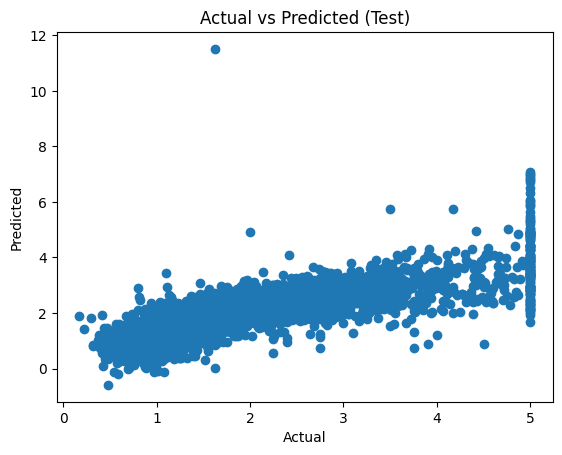

In [41]:

# ============================================================
# 5. REGRESSION
# ============================================================

reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

y_pred_test = reg_model.predict(X_test_scaled)

print("Regression MSE:", mean_squared_error(y_test, y_pred_test))
print("Regression R2:", r2_score(y_test, y_pred_test))

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Test)")
plt.show()



In [42]:
# ============================================================
# 6. CLASSIFICATION (3 CLASSES)
# ============================================================

y_class = pd.qcut(y, q=3, labels=[0,1,2])

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X, y_class, test_size=0.30, random_state=42
)

X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.50, random_state=42
)

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_c, y_train_c)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_c, y_train_c)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_c, y_train_c)

# ============================
# VALIDATION COMPARISON
# ============================

# Scale validation set
X_val_c_scaled = scaler.transform(X_val_c)

# Logistic Regression
log_val_pred = log_model.predict(X_val_c_scaled)
log_val_acc = accuracy_score(y_val_c, log_val_pred)

# Decision Tree
dt_val_pred = dt_model.predict(X_val_c_scaled)
dt_val_acc = accuracy_score(y_val_c, dt_val_pred)

# Random Forest
rf_val_pred = rf_model.predict(X_val_c_scaled)
rf_val_acc = accuracy_score(y_val_c, rf_val_pred)

print("Validation Accuracy Comparison:")
print("Logistic Regression:", log_val_acc)
print("Decision Tree:", dt_val_acc)
print("Random Forest:", rf_val_acc)

models = {
    "Logistic Regression": log_val_acc,
    "Decision Tree": dt_val_acc,
    "Random Forest": rf_val_acc
}

best_model_name = max(models, key=models.get)
print("Best Model based on Validation:", best_model_name)

y_pred_rf = rf_model.predict(X_test_c)

print("Random Forest Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print("confusion_matrix\n",confusion_matrix(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))



Validation Accuracy Comparison:
Logistic Regression: 0.7057493540051679
Decision Tree: 0.7222222222222222
Random Forest: 0.7965116279069767
Best Model based on Validation: Random Forest
Random Forest Accuracy: 0.8165374677002584
confusion_matrix
 [[893 128  14]
 [142 752 126]
 [ 18 140 883]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.74      0.74      0.74      1020
           2       0.86      0.85      0.86      1041

    accuracy                           0.82      3096
   macro avg       0.82      0.82      0.82      3096
weighted avg       0.82      0.82      0.82      3096



In [43]:
# ============================================================
# 7. SVM
# ============================================================

# Validation scaling
X_val_c_scaled = scaler.transform(X_val_c)

# Linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_c, y_train_c)
val_pred_linear = svm_linear.predict(X_val_c_scaled)
linear_val_acc = accuracy_score(y_val_c, val_pred_linear)

# RBF SVM
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_c, y_train_c)
val_pred_rbf = svm_rbf.predict(X_val_c_scaled)
rbf_val_acc = accuracy_score(y_val_c, val_pred_rbf)

print("Validation Accuracy:")
print("Linear SVM:", linear_val_acc)
print("RBF SVM:", rbf_val_acc)

if rbf_val_acc > linear_val_acc:
    best_svm = svm_rbf
    print("Selected Kernel: RBF")
else:
    best_svm = svm_linear
    print("Selected Kernel: Linear")


Validation Accuracy:
Linear SVM: 0.7063953488372093
RBF SVM: 0.7428940568475452
Selected Kernel: RBF


In [44]:
# Test scaling
X_test_c_scaled = scaler.transform(X_test_c)

# Random Forest Test Accuracy
rf_test_pred = rf_model.predict(X_test_c_scaled)
rf_test_acc = accuracy_score(y_test_c, rf_test_pred)

# Best SVM Test Accuracy
svm_test_pred = best_svm.predict(X_test_c_scaled)
svm_test_acc = accuracy_score(y_test_c, svm_test_pred)

print("\n=== Test Set Comparison ===")
print("Random Forest Test Accuracy:", rf_test_acc)
print("SVM Test Accuracy:", svm_test_acc)

C:\Users\KIIT0001\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



=== Test Set Comparison ===
Random Forest Test Accuracy: 0.3301033591731266
SVM Test Accuracy: 0.33430232558139533


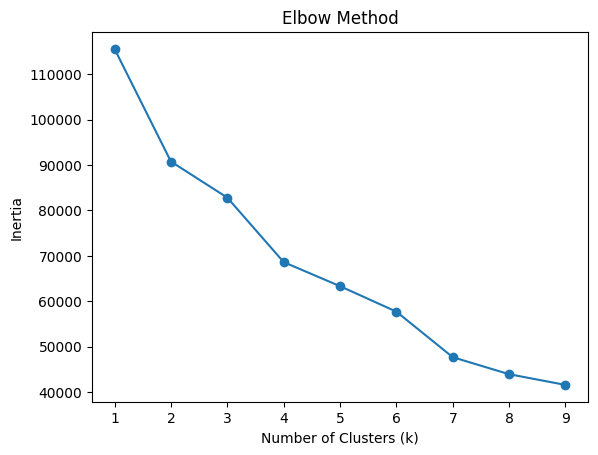

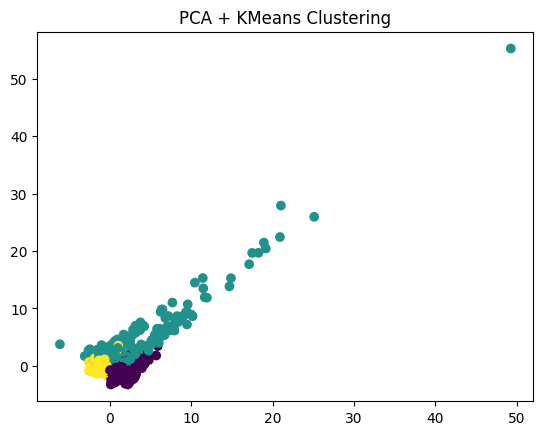

In [49]:
# ============================================================
# 8. CLUSTERING + PCA
# ============================================================
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("PCA + KMeans Clustering")
plt.show()



In [46]:
# ============================================================
# 9. NEURAL NETWORK
# ============================================================

mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_c, y_train_c)

y_pred_nn = mlp.predict(X_test_c)

print("Neural Network Accuracy:",
      accuracy_score(y_test_c, y_pred_nn))


Neural Network Accuracy: 0.7855297157622739


In [47]:

# ============================================================
# 10. SAVE BEST MODELS
# ============================================================

joblib.dump(reg_model, "regression_model.pkl")
joblib.dump(rf_model, "classification_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully!")


Models saved successfully!
